In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [2]:
df = pd.read_csv("../data/processed/music_memory_processed.csv")

In [3]:
y = df["melody_span"]

In [4]:
X = df.drop(
    columns=[
        "digit_span",
        "spatial_span",
        "melody_span"
    ]
)


In [5]:
X.dtypes

age                                  int64
sex                                    str
years_of_education                   int64
country                                str
ses_nuclear_family                 float64
gold_msi_musical_training            int64
gold_msi_general_sophistication      int64
gold_msi_active_engagement           int64
bfi_extraversion                     int64
bfi_agreeableness                    int64
bfi_conscientiousness                int64
bfi_negative_emotionality            int64
bfi_open_mindedness                  int64
dtype: object

In [6]:
X = pd.get_dummies(
    X,
    columns=["sex", "country"],
    drop_first=True,
    dtype=int
)

In [7]:
X.dtypes

age                                  int64
years_of_education                   int64
ses_nuclear_family                 float64
gold_msi_musical_training            int64
gold_msi_general_sophistication      int64
gold_msi_active_engagement           int64
bfi_extraversion                     int64
bfi_agreeableness                    int64
bfi_conscientiousness                int64
bfi_negative_emotionality            int64
bfi_open_mindedness                  int64
sex_male                             int64
sex_nonbinary                        int64
country_Australia                    int64
country_Austria                      int64
country_Belgium                      int64
country_Brazil                       int64
country_Canada                       int64
country_Finland                      int64
country_France                       int64
country_Germany                      int64
country_Italy                        int64
country_Netherlands                  int64
country_Nor

In [8]:
X.head()


,age,years_of_education,ses_nuclear_family,gold_msi_musical_training,gold_msi_general_sophistication,gold_msi_active_engagement,bfi_extraversion,bfi_agreeableness,bfi_conscientiousness,bfi_negative_emotionality,...,country_Finland,country_France,country_Germany,country_Italy,country_Netherlands,country_Norway,country_Portugal,country_Spain,country_UK,country_USA
0,29,18,8.0,43,112,50,45,52,49,31,...,0,0,0,0,0,0,0,0,0,0
1,21,16,64.5,32,83,39,38,52,33,38,...,0,0,0,0,0,0,0,0,0,0
2,23,16,22.0,48,121,55,45,59,53,21,...,0,0,0,0,0,0,0,0,0,0
3,30,15,20.5,39,106,34,48,49,51,28,...,0,0,0,0,0,0,0,0,0,0
4,26,17,38.0,43,111,54,33,46,51,29,...,0,0,0,0,0,0,0,0,0,0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[0. ,0.17,0.04,...,3.67,1.33,1.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](28,)","['age','years_of_education','ses_nuclear_family',...,'country_Spain', 'country_UK','country_USA']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.63
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)


In [12]:
y_pred = model.predict(X_test)

In [13]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,29.5,29.575960
1,28.5,32.377483
2,18.5,19.932554
3,24.5,30.701795
4,22.5,27.652365
5,17.5,23.246253
6,19.5,23.116247
7,19.0,22.858379
8,19.5,26.695259
9,23.5,24.028152


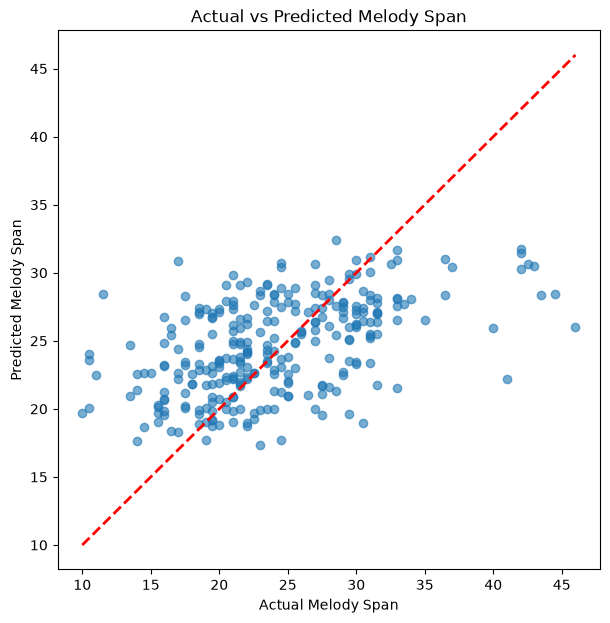

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Melody Span")
plt.ylabel("Predicted Melody Span")
plt.title("Actual vs Predicted Melody Span")

plt.show()

In [15]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 4.35
RMSE : 5.61
R²   : 0.249


## Model Evaluation Results

The baseline Linear Regression model achieved the following performance on the testing dataset:

| Metric | Value |
|---------|------:|
| Mean Absolute Error (MAE) | 4.35 |
| Root Mean Squared Error (RMSE) | 5.61 |
| Coefficient of Determination (R²) | 0.249 |

### Interpretation

- The model predicts Melody Span with an average error of approximately **4.35 points**.
- The higher RMSE relative to MAE indicates the presence of a small number of larger prediction errors.
- The model explains approximately **24.9% of the variance** in Melody Span, suggesting that demographic characteristics, personality traits, and musical experience collectively contribute meaningful information for predicting auditory working memory performance.
- Although the model does not account for all variability in Melody Span, its performance is consistent with expectations for behavioral and cognitive science datasets, where substantial individual differences and unmeasured factors influence performance.

In [17]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
15,country_Belgium,4.241880
19,country_France,4.212505
25,country_Spain,3.665660
16,country_Brazil,3.107951
21,country_Italy,2.776242
24,country_Portugal,2.453210
18,country_Finland,2.303756
13,country_Australia,2.148378
17,country_Canada,1.708239
14,country_Austria,1.672710


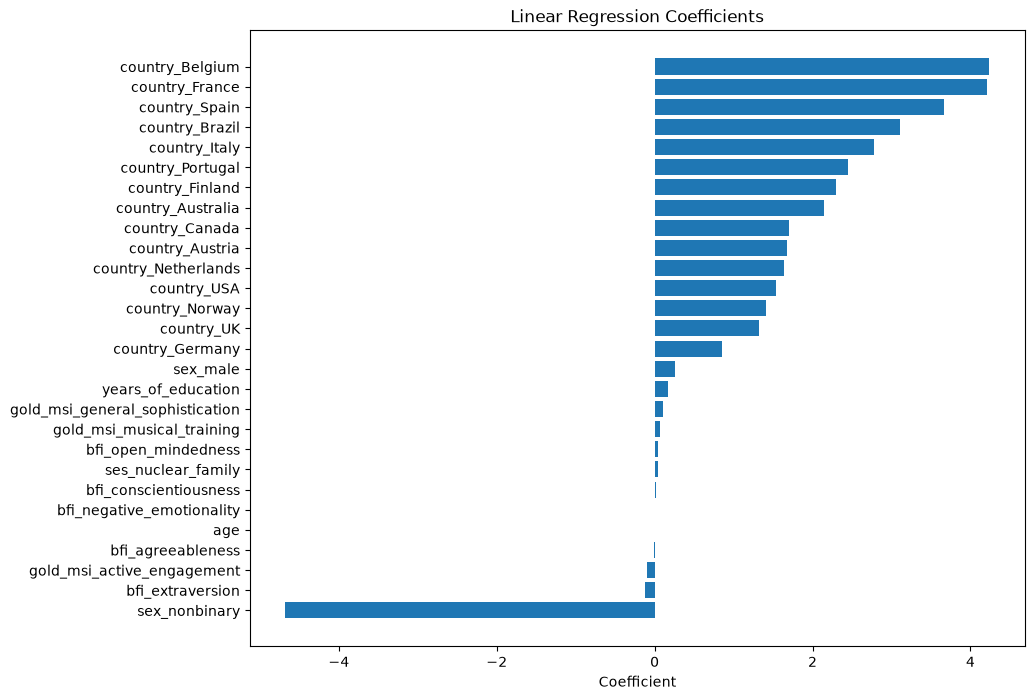

In [18]:
import matplotlib.pyplot as plt

coefficients_sorted = coefficients.sort_values("Coefficient")

plt.figure(figsize=(10,8))

plt.barh(
    coefficients_sorted["Feature"],
    coefficients_sorted["Coefficient"]
)

plt.xlabel("Coefficient")

plt.title("Linear Regression Coefficients")

plt.show()

In [38]:
X_refined = df.drop(
    columns=[
        "digit_span",
        "spatial_span",
        "melody_span",
        "country",
        "sex"
    ]
)

In [39]:
from sklearn.preprocessing import StandardScaler

In [41]:
numeric_columns = [
    "age",
    "years_of_education",
    "ses_nuclear_family",
    "gold_msi_musical_training",
    "gold_msi_general_sophistication",
    "gold_msi_active_engagement",
    "bfi_extraversion",
    "bfi_agreeableness",
    "bfi_conscientiousness",
    "bfi_negative_emotionality",
    "bfi_open_mindedness"
]

In [42]:
X_refined[numeric_columns] = scaler.fit_transform(
    X_refined[numeric_columns]
)

In [43]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_refined,
    y,
    test_size=0.20,
    random_state=42
)

In [44]:
refined_model = LinearRegression()

refined_model.fit(
    X_train_r,
    y_train_r
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[0.24,0.2 ,0.57,...,0.27,0.06,0.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['age','years_of_education','ses_nuclear_family',..., 'bfi_conscientiousness','bfi_negative_emotionality','bfi_open_mindedness']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,24.62
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [45]:
y_pred_r = refined_model.predict(
    X_test_r
)

In [46]:
mae_r = mean_absolute_error(y_test_r, y_pred_r)

rmse_r = np.sqrt(
    mean_squared_error(y_test_r, y_pred_r)
)

r2_r = r2_score(
    y_test_r,
    y_pred_r
)

print(f"MAE  : {mae_r:.2f}")
print(f"RMSE : {rmse_r:.2f}")
print(f"R²   : {r2_r:.3f}")

MAE  : 4.33
RMSE : 5.61
R²   : 0.248


In [47]:
coefficients_refined = pd.DataFrame({
    "Feature": X_train_r.columns,
    "Coefficient": refined_model.coef_
})

coefficients_refined = coefficients_refined.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients_refined

,Feature,Coefficient
4,gold_msi_general_sophistication,2.313391
3,gold_msi_musical_training,1.347048
2,ses_nuclear_family,0.570174
10,bfi_open_mindedness,0.444835
8,bfi_conscientiousness,0.270545
0,age,0.240112
1,years_of_education,0.197456
9,bfi_negative_emotionality,0.063893
7,bfi_agreeableness,-0.124860
5,gold_msi_active_engagement,-0.784331


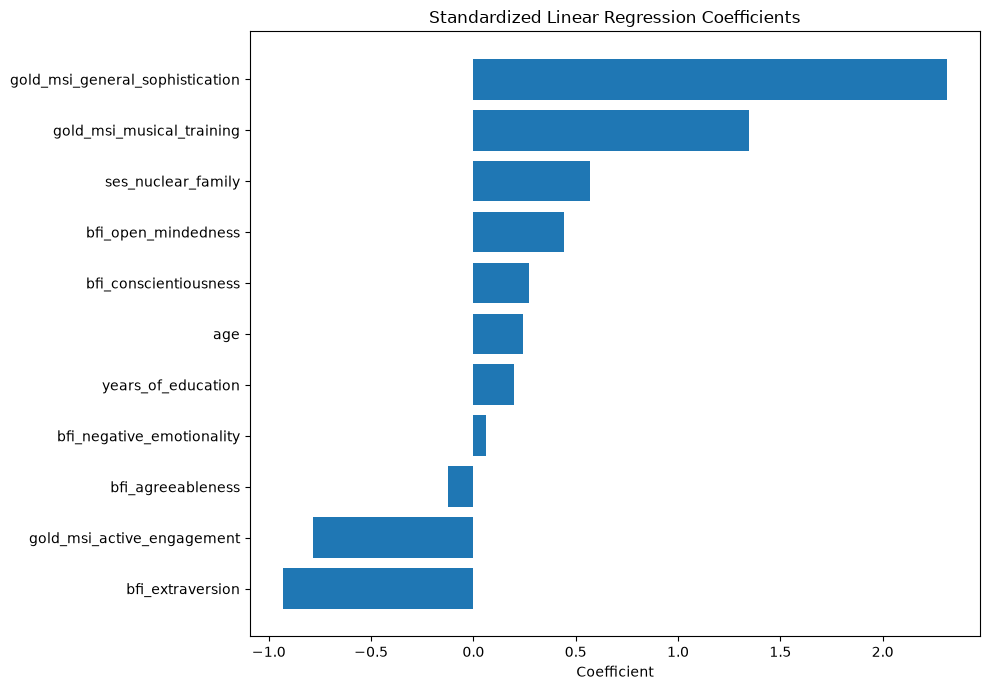

In [48]:
plt.figure(figsize=(10,7))

coefficients_refined = coefficients_refined.sort_values("Coefficient")

plt.barh(
    coefficients_refined["Feature"],
    coefficients_refined["Coefficient"]
)

plt.title("Standardized Linear Regression Coefficients")
plt.xlabel("Coefficient")

plt.tight_layout()
plt.show()

# Results and Interpretation

The final Linear Regression model explained **24.8% of the variance** in Melody Span performance (R² = 0.248), with an average prediction error of **4.33 Melody Span points**.

Among all predictors, **Gold-MSI General Sophistication** and **Gold-MSI Musical Training** exhibited the largest positive standardized coefficients, indicating that musical experience was the strongest predictor of auditory working memory performance within the dataset.

Socioeconomic status and Open-Mindedness demonstrated smaller positive associations with Melody Span, whereas demographic variables such as Age and Years of Education contributed relatively little after controlling for the remaining predictors.

The negative coefficient associated with Active Musical Engagement is likely attributable to shared variance with other musical experience measures rather than indicating a negative relationship with memory performance.

Overall, the findings support the hypothesis that individuals with greater musical experience tend to demonstrate superior Melody Span performance. However, because the data are observational, these findings should be interpreted as **associations rather than evidence of causality**.

In [50]:
y_digit = df["digit_span"]

In [51]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_refined,
    y_digit,
    test_size=0.20,
    random_state=42
)

In [52]:
digit_model = LinearRegression()

digit_model.fit(
    X_train_d,
    y_train_d
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0. , 0.08, 0.35,..., 0.04,-0.11, 0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['age','years_of_education','ses_nuclear_family',..., 'bfi_conscientiousness','bfi_negative_emotionality','bfi_open_mindedness']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [53]:
y_pred_d = digit_model.predict(
    X_test_d
)

In [54]:
mae_d = mean_absolute_error(
    y_test_d,
    y_pred_d
)

rmse_d = np.sqrt(
    mean_squared_error(
        y_test_d,
        y_pred_d
    )
)

r2_d = r2_score(
    y_test_d,
    y_pred_d
)

print(f"MAE  : {mae_d:.2f}")
print(f"RMSE : {rmse_d:.2f}")
print(f"R²   : {r2_d:.3f}")

MAE  : 1.83
RMSE : 2.24
R²   : -0.006


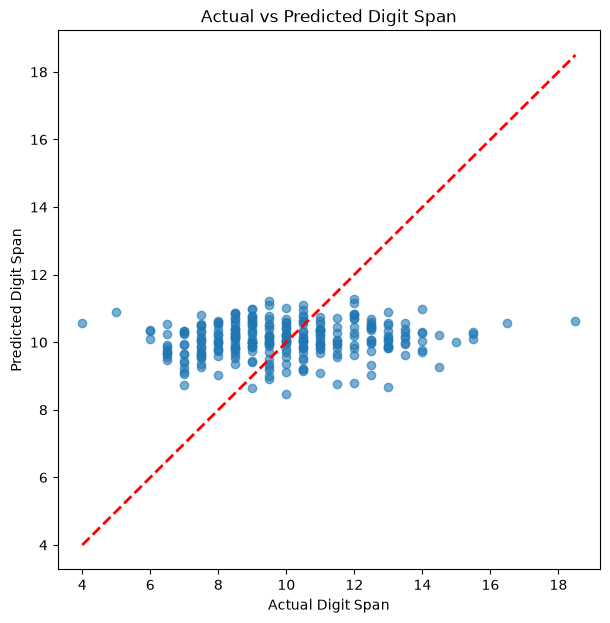

In [55]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_d,
    y_pred_d,
    alpha=0.6
)

plt.plot(
    [y_test_d.min(), y_test_d.max()],
    [y_test_d.min(), y_test_d.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Digit Span")
plt.ylabel("Predicted Digit Span")

plt.title("Actual vs Predicted Digit Span")

plt.show()

In [64]:
digit_coefficients = pd.DataFrame({
    "Feature": X_train_d.columns,
    "Coefficient": digit_model.coef_
})

digit_coefficients = digit_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

digit_coefficients

,Feature,Coefficient
4,gold_msi_general_sophistication,0.693109
2,ses_nuclear_family,0.345583
1,years_of_education,0.080368
8,bfi_conscientiousness,0.039510
10,bfi_open_mindedness,0.022848
0,age,0.003086
7,bfi_agreeableness,-0.075789
9,bfi_negative_emotionality,-0.108134
5,gold_msi_active_engagement,-0.175873
6,bfi_extraversion,-0.304524


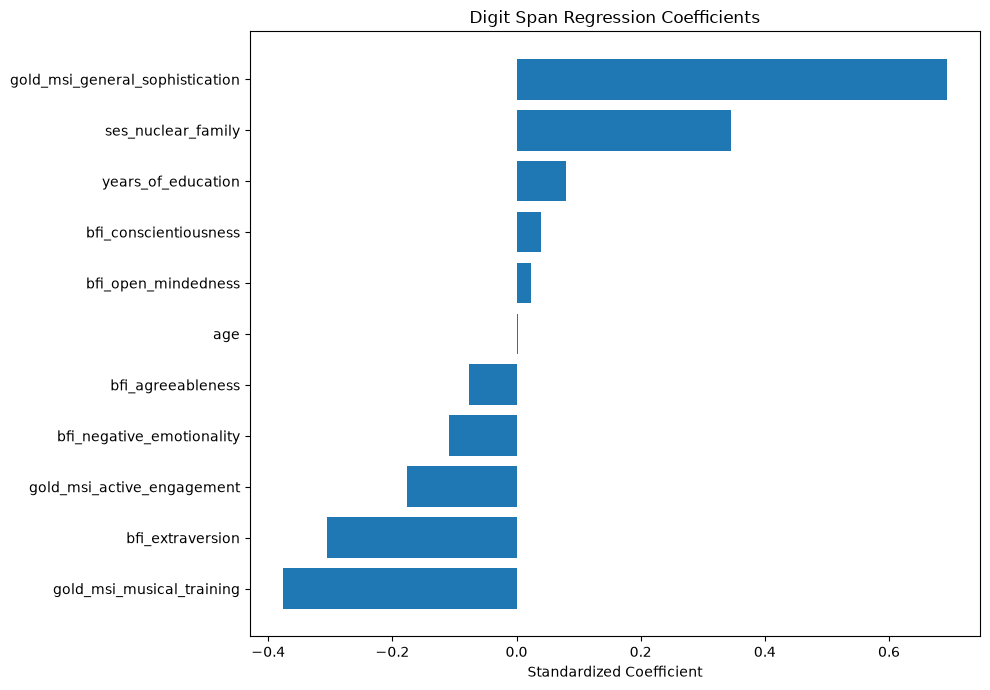

In [65]:
plt.figure(figsize=(10,7))

digit_coefficients = digit_coefficients.sort_values(
    "Coefficient"
)

plt.barh(
    digit_coefficients["Feature"],
    digit_coefficients["Coefficient"]
)

plt.xlabel("Standardized Coefficient")

plt.title("Digit Span Regression Coefficients")

plt.tight_layout()

plt.show()

In [56]:
y_spatial = df["spatial_span"]

In [57]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_refined,
    y_spatial,
    test_size=0.20,
    random_state=42
)

In [58]:
spatial_model = LinearRegression()

spatial_model.fit(
    X_train_s,
    y_train_s
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[-0.04, 0.11, 0.13,...,-0.07,-0.19, 0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['age','years_of_education','ses_nuclear_family',..., 'bfi_conscientiousness','bfi_negative_emotionality','bfi_open_mindedness']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.74
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [59]:
y_pred_s = spatial_model.predict(
    X_test_s
)

In [60]:
mae_s = mean_absolute_error(
    y_test_s,
    y_pred_s
)

rmse_s = np.sqrt(
    mean_squared_error(
        y_test_s,
        y_pred_s
    )
)

r2_s = r2_score(
    y_test_s,
    y_pred_s
)

print(f"MAE  : {mae_s:.2f}")
print(f"RMSE : {rmse_s:.2f}")
print(f"R²   : {r2_s:.3f}")

MAE  : 1.42
RMSE : 2.04
R²   : 0.026


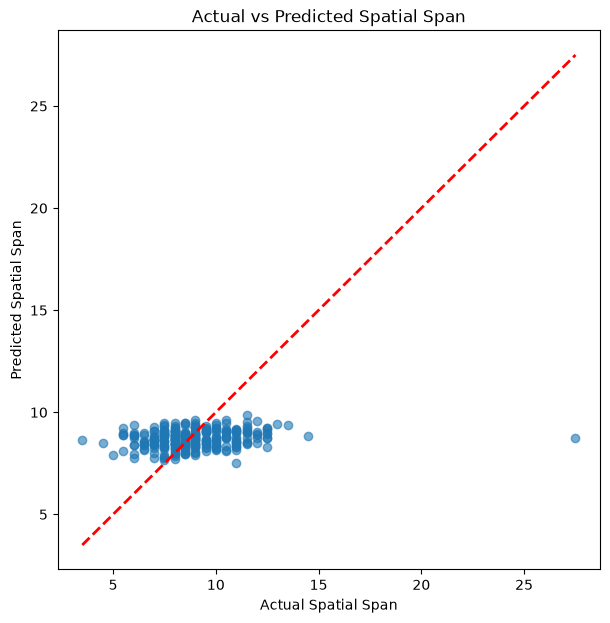

In [61]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_s,
    y_pred_s,
    alpha=0.6
)

plt.plot(
    [y_test_s.min(), y_test_s.max()],
    [y_test_s.min(), y_test_s.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Spatial Span")
plt.ylabel("Predicted Spatial Span")

plt.title("Actual vs Predicted Spatial Span")

plt.show()

In [62]:
spatial_coefficients = pd.DataFrame({
    "Feature": X_train_s.columns,
    "Coefficient": spatial_model.coef_
})

spatial_coefficients = spatial_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

spatial_coefficients

,Feature,Coefficient
3,gold_msi_musical_training,0.411883
2,ses_nuclear_family,0.129528
1,years_of_education,0.109329
10,bfi_open_mindedness,0.020182
0,age,-0.044981
4,gold_msi_general_sophistication,-0.057135
8,bfi_conscientiousness,-0.069523
7,bfi_agreeableness,-0.099469
5,gold_msi_active_engagement,-0.114493
6,bfi_extraversion,-0.177223


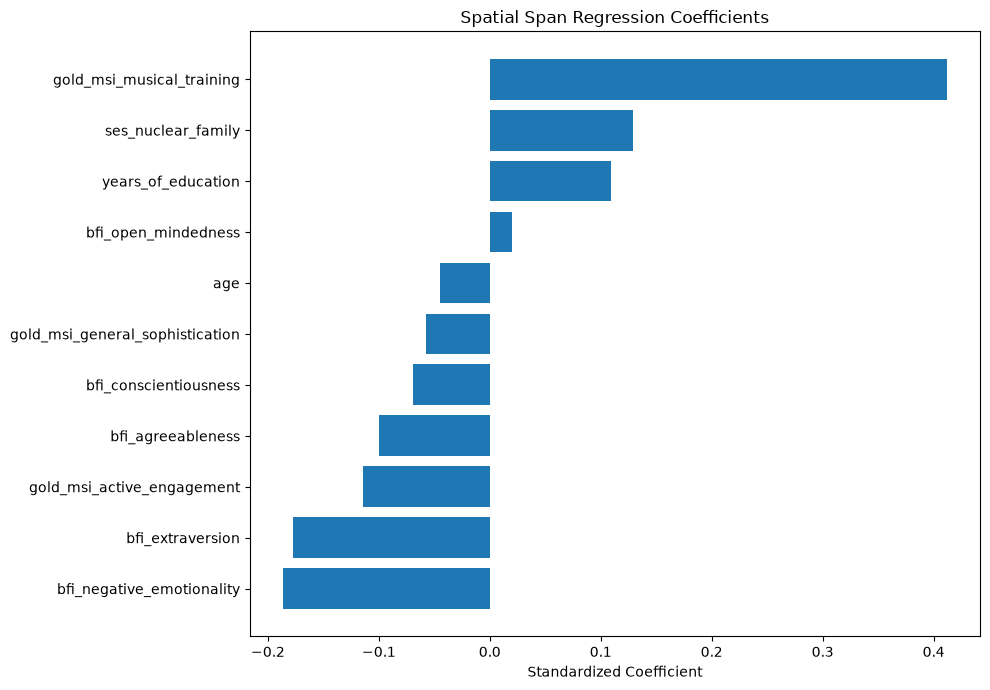

In [63]:
plt.figure(figsize=(10,7))

spatial_coefficients = spatial_coefficients.sort_values(
    "Coefficient"
)

plt.barh(
    spatial_coefficients["Feature"],
    spatial_coefficients["Coefficient"]
)

plt.xlabel("Standardized Coefficient")

plt.title("Spatial Span Regression Coefficients")

plt.tight_layout()

plt.show()

# Overall Findings

Three Linear Regression models were developed to investigate whether demographic characteristics, personality traits, socioeconomic status, and musical experience predict different domains of working memory.

| Memory Task | MAE | RMSE | R² |
|-------------|----:|-----:|----:|
| Melody Span | 4.33 | 5.61 | 0.248 |
| Digit Span | 1.83 | 2.24 | -0.006 |
| Spatial Span | 1.42 | 2.04 | 0.026 |

The results demonstrate a clear difference across memory domains.

The Melody Span model achieved substantially higher predictive performance than the Digit Span and Spatial Span models. Musical experience variables, particularly Gold-MSI General Sophistication and Gold-MSI Musical Training, consistently emerged as the strongest positive predictors of Melody Span.

In contrast, the models for Digit Span and Spatial Span explained very little variance, indicating that the selected predictors provide limited information for predicting verbal and visuospatial working memory.

Overall, these findings support the hypothesis that musical experience is more strongly associated with **auditory working memory** than with working memory performance in general.

Because the study is based on observational data, these findings should be interpreted as **associations rather than evidence of causality**.